<p style="padding:5px;
          background-color:#afa;
          border:1px solid #bbffbb;
          border-radius:20px;
          font-weight:bold;
          font-size:2em;
          padding:15px;
          text-align:center;">
    ➗ Diviser Pour Régner : Complexité du le tri fusion 🤴

</p><br> 

## I. Fonction tri_fusion

Nous redonnons ici : 

In [29]:
def fusion(l1, l2):
    """
    Précondition : l1 et l2 sont deux listes triées
    Postcondition : la fonction renvoie une liste triée constituée de la fusion 
    de l1 et l2
    Exemple :
    fusion([2, 3, 5, 8],[1, 4]) renvoie [1, 2, 3, 5, 8]
    """
    n1 = len(l1)
    n2 = len(l2)
    lst = [] # initialisation de la fusion de l1 et l2 
    i1 = 0 # indice qui sert à parcourir l1
    i2 = 0 # indice qui sert à parcourir l2
    while i1 < n1 and i2 < n2 :
        if l1[i1] < l2[i2]:
            lst.append(l1[i1])
            i1 = i1 + 1
        else :
            lst.append(l2[i2])
            i2 = i2 + 1
    if i1 == n1:
        return lst + l2[i2:]
    if i2 == n2:
        return lst + l1[i1:]


In [30]:
fusion([2, 3, 5, 8],[1, 4])   

fusion([1, 4],[2, 3, 5, 8]) 

[1, 2, 3, 4, 5, 8]

In [31]:
def tri_fusion(lst):
    """
    Précondition : lst est une liste
    Postcondition : la fonction renvoie une liste qui est la liste triée

    """
    n = len(lst)
    if n <= 1:
        return lst
    else :
        m = n // 2
        return fusion(tri_fusion(lst[:m]), tri_fusion(lst[m:])) 

tab = [4, 3, 8, 2, 7, 1, 5]

print(tri_fusion(tab))
print(tab)
assert tri_fusion([1, 2, 3 , 4]) == [1, 2, 3 , 4]
assert tri_fusion([4, 3, 2, 1]) == [1, 2, 3 , 4]
assert tri_fusion([4, 2, 3 , 1]) == [1, 2, 3 , 4]

[1, 2, 3, 4, 5, 7, 8]
[4, 3, 8, 2, 7, 1, 5]


# II. Comparaison des complexités

Nous avons vu dans la vidéo que le tri fusion d'une liste de taille $n$ avait une complexité en $O(n \text{log}_2(n))$.   
En première nous avons vu que le tri par sélection était de complexité en $O(n^2)$

## 1. Comparaison avec le tri par sélection

### 💻 A vous de jouer 1 :

Compléter le script suivant :  
Il faut être très patient...

⌛ Il faut être très patient...

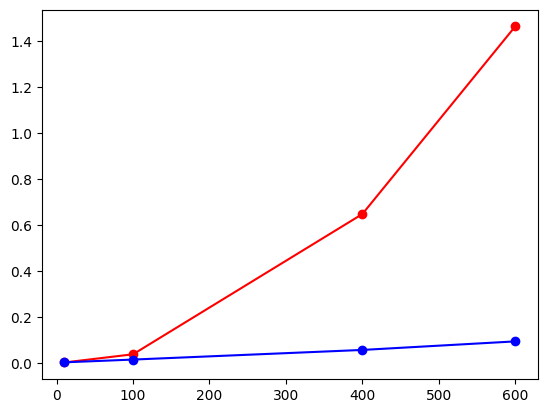

In [38]:
import timeit
import matplotlib.pyplot as plt
from random import shuffle

def tri_selection(liste: list[int]):
    """
    liste est de type liste
    La fonction renvoie la liste triee par ordre croissant.
    Elle utilise l'algorithme de tri par selection. C'est un tri "en place"
    """
    index_exterior: int = 0
    index_interior: int = 0
    while index_exterior < len(liste):

        index_interior = index_exterior
        current_min: int = liste[index_interior]
        index_min: int = index_interior

        while index_interior < len(liste):

            if liste[index_interior] < current_min:
                current_min = liste[index_interior]
                index_min = index_interior
            index_interior += 1
        
        value_temporary: int = liste[index_exterior]
        liste[index_exterior] = liste[index_min]
        liste[index_min] = value_temporary

        index_exterior += 1


# différentes tailles de listes
abscisse =  [10, 100, 400, 600]

ordonnee_selection = [] # liste des temps par tri sélection
ordonnee_fusion = [] # liste des temps par tri fusion avec slices

# Création des listes non triées de tailles n
for n in abscisse:
    l = [i for i in range(n)] # création de la liste de taille n : [0... n-1]
    shuffle(l) # mélange de cette liste

    # Création des listes d'ordonnées correspondantes pour chaque graphique
    # Pour  le tri par sélection :
    # Attention le tri sélection est un tri "en place" qui trie la liste l. 
    # Il faut donc pour chaque mesure prendre une copie de la liste l initiale, avec l[:]
    temps=timeit.timeit("tri_selection(l[:])", number=100, globals=globals())
    ordonnee_selection.append(temps)

    # Par tri fusion avec slices
    temps=timeit.timeit("tri_fusion(l)", number=100, globals=globals())
    ordonnee_fusion.append(temps)


# Graphique pour le tri sélection en rouge
plt.plot(abscisse, ordonnee_selection, "ro-") # en rouge

# Graphique pour le tri fusion avec slices en bleu
plt.plot(abscisse, ordonnee_fusion, "bo-") # en bleu



plt.show()
plt.close()


### 2. Comparaison avec le tri par insertion

### 💻 A vous de jouer 2 :  
Procéder de même pour comparer le tri fusion au tri par insertion.

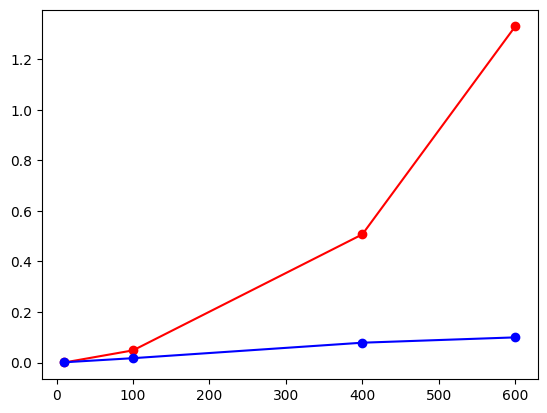

In [44]:
# Votre code :
import timeit
import matplotlib.pyplot as plt
from random import shuffle

def tri_insertion(liste: list[int]):
    exterior: int = 0
    interior: int = 0
    while exterior < len(liste):
        interior = exterior
        while interior > 0 and liste[interior - 1] > liste[interior]:
            swap: int = liste[interior - 1]
            liste[interior - 1] = liste[interior]
            liste[interior] = swap
            interior -= 1
        exterior += 1


# différentes tailles de listes
abscisse =  [10, 100, 400, 600]

ordonnee_insertion = [] # liste des temps par tri sélection
ordonnee_fusion = [] # liste des temps par tri fusion avec slices

# Création des listes non triées de tailles n
for n in abscisse:
    l = [i for i in range(n)] # création de la liste de taille n : [0... n-1]
    shuffle(l) # mélange de cette liste

    # Création des listes d'ordonnées correspondantes pour chaque graphique
    # Pour  le tri par sélection :
    # Attention le tri sélection est un tri "en place" qui trie la liste l. 
    # Il faut donc pour chaque mesure prendre une copie de la liste l initiale, avec l[:]
    temps=timeit.timeit("tri_insertion(l[:])", number=100, globals=globals())
    ordonnee_insertion.append(temps)

    # Par tri fusion avec slices
    temps=timeit.timeit("tri_fusion(l)", number=100, globals=globals())
    ordonnee_fusion.append(temps)


# Graphique pour le tri sélection en rouge
plt.plot(abscisse, ordonnee_insertion, "ro-") # en rouge

# Graphique pour le tri fusion avec slices en bleu
plt.plot(abscisse, ordonnee_fusion, "bo-") # en bleu



plt.show()
plt.close()




<p style="padding:5px;
          background-color:#afa;
          border:1px solid #bbffbb;
          border-radius:20px;
          font-weight:bold;
          font-size:1.2em;
          padding:15px;
          text-align:center;">
    <b>Conclusion :</b>   <br>
😊 On observe bien cette différence d'efficacité.   <br>
    Gagnant : le tri fusion

</p><br> 


Mireille COILHAC  
<a rel="license" href="http://creativecommons.org/licenses/by-nc-sa/4.0/"><img alt="Creative Commons License" style="border-width:0" src="https://i.creativecommons.org/l/by-nc-sa/4.0/88x31.png" /></a><br />This work is licensed under a <a rel="license" href="http://creativecommons.org/licenses/by-nc-sa/4.0/">Creative Commons Attribution-NonCommercial-ShareAlike 4.0 International License</a>.


